Analysis of the aggregated cell survival data
- With classic LQ fit
- With unweighted Rorvik

In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from sklearn.metrics import r2_score

CHANGE THESE: the relevant folder and file paths

In [2]:
#enter list of paths to results folders here
results_folders = [r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Analysis Corrected results 16 Oct", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Analysis Corrected results 30 Oct", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Analysis Corrected results 18 Nov"] 

#enter list of multiplicity file paths here
multi_x = [r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Multiplicity X-ray 16-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Multiplicity X-ray 30-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Multiplicity X-ray 18-11.xlsx"]
multi_p = [r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Multiplicity proton 16-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Multiplicity proton 30-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Multiplicity proton 18-11.xlsx"]

Loading and importing data.

In [3]:
def write_fractions_dic(path):
    data = pd.read_excel(path)
    
    total = np.array(data['Total'])[-1]

    fractions_dic = {}

    for column in data.items():
        if column[0] != 'Sample' and column[0] != 'Total': #ignore first and last column
            size = column[0]
            count = np.array(column[1])[-1]

            frac = count/total

            fractions_dic[size] = frac

    return fractions_dic

In [4]:
def cfu_survival_func(s, dic, SF):
    sum = 0
    for key, frac in dic.items():
        power = np.power((1-s),int(key))
        sum += frac*(1-power)
    
    #subtract the SF to use root
    sum -= SF
    return sum

In [5]:
def Parse_data(input, exp, fractions_dic):
    #Split colony counting data into cell survival for each sample
    #The survival is calculated for each triplicate separately and normalised to control
    #Also write LET to output for Rorvik calculations

    #inputs:
    #input = dataframe with the dose, plated cells and count of each triplicate for each sample, Format [Dose Plated Count1 Count2 Count3]

    #outputs:
    #output = dataframe with survival per triplicate and LET, Format [Dose LET Survival]

    def write_LET(rad_type):
        if rad_type == 'X':
            return 2.02
        if rad_type == 'Proton L':
            return 1.3
        if rad_type == 'Proton H':
            return 16.0

    triplicates = ['Count_1', 'Count_2', 'Count_3']

    #Isolate controls, calculate control survival for normalising
    control_data = input[input['Dose'] == 0]
    control_survival = control_data[triplicates].mean(axis=1)/control_data['Plated']

    #Write data to output with dose and survival
    output = pd.DataFrame(columns=['Dose', 'LET', 'Survival'])

    #Loop through rows of input to process data and write to output.
    #Each triplicate is processed separately
    for row in input.itertuples():
        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_1/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_2/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_3/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

    return output



In [23]:
#Load and process data

#Loop through folders to extract all excels and write to dataframes: rorvik for aggregating all data for Rorvik fit, survival for mean survival per experiment LQ
X = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])
PL = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])
PH = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])

for i in range(len(results_folders)):
    folder = results_folders[i]
    multiplicity_x = write_fractions_dic(multi_x[i])
    multiplicity_p = write_fractions_dic(multi_p[i])
    for file in os.listdir(folder):
        if os.path.splitext(os.path.join(folder, file))[-1] == '.xlsx':
            #Read in if it's an excel file
            df = pd.read_excel(os.path.join(folder, file), index_col=None)

            #Check the radiation type and write to correct dataframe
            if df.tail(1)['Rad'].item() == 'X':
                data = Parse_data(df, i+1, multiplicity_x)
                #Correct X-ray dose
                data['Dose'] = 0.85*data['Dose']
                #take out experiment 3
                if i != 2:
                    X = pd.concat([X, data])   
            if df.tail(1)['Rad'].item() == 'Proton L':
                data = Parse_data(df, i+1, multiplicity_p)
                #Correct Proton low dose
                data['Dose'] = 0.96*data['Dose']
                PL = pd.concat([PL, data])
            if df.tail(1)['Rad'].item() == 'Proton H':
                PH = pd.concat([PH, Parse_data(df, i+1, multiplicity_p)])



C:\Users\bhaan\AppData\Local\Temp\ipykernel_26840\3774299479.py:36: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
C:\Users\bhaan\AppData\Local\Temp\ipykernel_26840\3774299479.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_26840\4179169624.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result d

# Perform LQ fit on data

In [7]:
def Process_data(input):
    #Process [Dose Survival] data per sample into a mean and std per triplicate

    #inputs
    #df = dataframe [Dose Survival Experiment] per sample as outputted by the cell loading the data

    #output
    #df_means = dataframe ['Dose' 'Mean Survival' 'Experiment] per triplicate
    #df_stds = standard deviation of log of survival per triplicate

    #copy the input for processing
    df = input.copy()

    #Process into mean and std per triplicate
    df_means = pd.DataFrame(columns=['Dose', 'Mean Survival'])
    df_stds = np.zeros([1, int(len(df)/3)])

    for i in range(int(len(df)/3)):
        #Select triplicate
        trip = df[(i*3):((i+1)*3)]
        newrow = {}

        #Write dose
        newrow['Dose'] = trip['Dose'].iloc[0]
        newrow['Experiment'] = trip['Experiment'].iloc[0]

        #Calculate mean, ignoring any NaN values
        newrow['Mean Survival'] = np.nanmean(np.array(trip['Survival']))
        df_means = pd.concat([df_means, pd.DataFrame([newrow])])

        #Write standard dev
        df_stds[0][i] = np.nanstd(np.array(trip['Survival']))

    return df_means, df_stds 

In [8]:
def Perform_LQ_fit(sample):
    #Generate LQ fit

    #inputs:
    #sample = dataframe as ['Dose' 'Mean Survival'] for all triplicates, as outputted by 'Process_data'

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations

    def LQ_function(d, a, b):
        return np.exp(-(a*d + b*(np.square(d))))

    x = np.array(sample['Dose'], dtype='float')
    y = np.array(sample['Mean Survival'], dtype = 'float')

    p0 = (0.1, 0.1)

    popt, pcov = curve_fit(LQ_function, x, y, p0=p0, bounds=(0,1))
    
    return popt, LQ_function

In [9]:
def Perform_LQ_fit_intcpt(sample):
    #Generate LQ fit

    #inputs:
    #sample = dataframe as ['Dose' 'Mean Survival'] for all triplicates, as outputted by 'Process_data'

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations

    def LQ_func_intcpt(d, a, b, c):
        return np.exp(-(a*d + b*(np.square(d)) + c))

    x = np.array(sample['Dose'], dtype='float')
    y = np.array(sample['Mean Survival'], dtype = 'float')

    p0 = (0.1, 0.1, 0.1)

    popt, pcov = curve_fit(LQ_func_intcpt, x, y, p0=p0, bounds=(0,1))
    
    return popt, LQ_func_intcpt

In [10]:
def LQ_func(d, a, b):
        return np.exp(-(a*d + b*(np.square(d))))

In [11]:
def LQ_func_intcpt(d, a, b, c):
        return np.exp(-(a*d + b*(np.square(d)) + c))

In [24]:
#Process data into means and standard devs for all
X_means, X_stds = Process_data(X) 
PL_means, PL_stds = Process_data(PL)
PH_means, PH_stds = Process_data(PH)

#Dose uncertainties
#X-ray dose uncertainty obtained from the experiments with Michel as described in my notebook on 2/12/2025
X_dose_err = pd.DataFrame({'Dose':X_means['Dose'], 'Err': 0.071*X_means['Dose'], 'Exp': X_means['Experiment']})
#Proton dose uncertainties obtained from dosimetry, as described in dosimetry final
PL_dose_err = pd.DataFrame({'Dose':PL_means['Dose'], 'Err': 0.029*PL_means['Dose'], 'Exp': PL_means['Experiment']})
PH_dose_err = pd.DataFrame({'Dose':PH_means['Dose'], 'Err': 0.038*PH_means['Dose'], 'Exp': PH_means['Experiment']})


C:\Users\bhaan\AppData\Local\Temp\ipykernel_26840\1658721451.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means = pd.concat([df_means, pd.DataFrame([newrow])])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_26840\1658721451.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means = pd.concat([df_means, pd.DataFrame([newrow])])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_26840\1658721451.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is dep

# Exclude 8 Gy point

In [13]:
PH_means = PH_means.loc[PH_means['Dose'] != 8]
PH_dose_err= PH_dose_err.loc[PH_dose_err['Dose'] != 8]
PH_stds = pd.DataFrame(np.transpose(PH_stds))

params_ph = Perform_LQ_fit(PH_means)
params_ph = params_ph[0]

pred = np.array(PH_means['Dose'])
r2_ph = r2_score(PH_means['Mean Survival'], LQ_func(pred.astype('float'), params_ph[0], params_ph[1]))

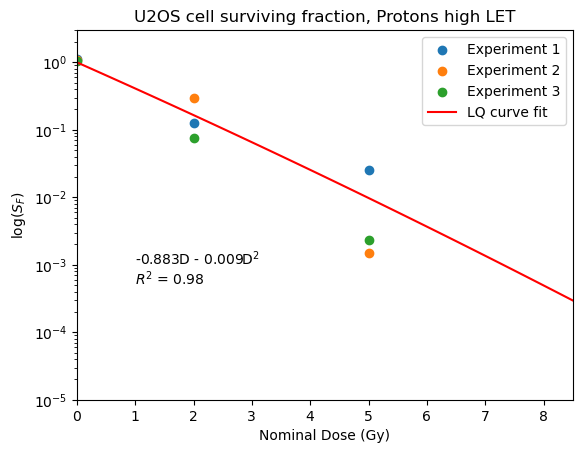

In [ ]:
#Plot Protons High
for i in range(len(np.unique(np.array(PH_means['Experiment'])))):
    exp = np.unique(np.array(PH_means['Experiment']))[i]
    data = PH_means[PH_means['Experiment']==exp]
    error = PH_stds[0][i*3:(i+1)*3]
    dose_error = PH_dose_err[PH_dose_err['Exp']== exp]
    plt.scatter(data['Dose'], data['Mean Survival'], label=f'Experiment {int(exp)}')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_ph[0], params_ph[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, Protons high LET')
plt.text(1, 0.001, f"-{round(params_ph[0],3)}D - {round(params_ph[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

# Plot only with 5 and 8 Gy

In [18]:
PH_means = PH_means.loc[PH_means['Dose'] != 0]
PH_means = PH_means.loc[PH_means['Dose'] != 2]
PH_dose_err= PH_dose_err.loc[PH_dose_err['Dose'] != 0]
PH_dose_err= PH_dose_err.loc[PH_dose_err['Dose'] != 2]
PH_stds = pd.DataFrame(np.transpose(PH_stds))

params_ph_xtra = Perform_LQ_fit_intcpt(PH_means)
params_ph_xtra = params_ph_xtra[0]

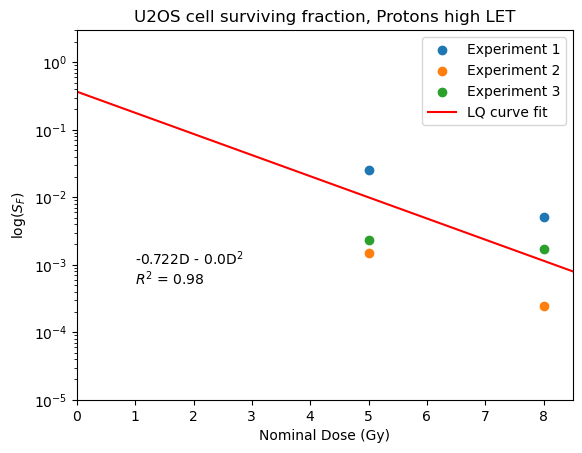

In [22]:
#Plot Protons High
for i in range(len(np.unique(np.array(PH_means['Experiment'])))):
    exp = np.unique(np.array(PH_means['Experiment']))[i]
    data = PH_means[PH_means['Experiment']==exp]
    error = PH_stds[0][i*3:(i+1)*3]
    dose_error = PH_dose_err[PH_dose_err['Exp']== exp]
    plt.scatter(data['Dose'], data['Mean Survival'], label=f'Experiment {int(exp)}')
plt.plot(np.linspace(0, 10, 100), LQ_func_intcpt(np.linspace(0, 10, 100), params_ph_xtra[0], params_ph_xtra[1], params_ph_xtra[2]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, Protons high LET')
plt.text(1, 0.001, f"-{round(params_ph_xtra[0],3)}D - {round(params_ph_xtra[1],3)}D$^2$")
plt.text(1, 0.0005, f"$R^2$ = {round(r2_ph, 2)}")
plt.xlim([0, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

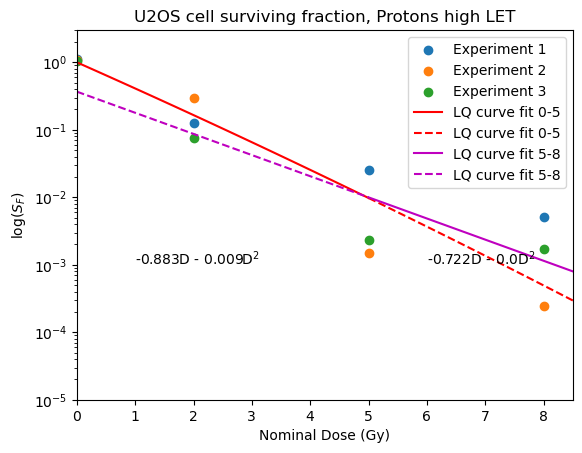

In [30]:
for i in range(len(np.unique(np.array(PH_means['Experiment'])))):
    exp = np.unique(np.array(PH_means['Experiment']))[i]
    data = PH_means[PH_means['Experiment']==exp]
    error = PH_stds[0][i*3:(i+1)*3]
    dose_error = PH_dose_err[PH_dose_err['Exp']== exp]
    plt.scatter(data['Dose'], data['Mean Survival'], label=f'Experiment {int(exp)}')

plt.plot(np.linspace(0, 5, 100), LQ_func(np.linspace(0, 5, 100), params_ph[0], params_ph[1]), color='r', label='LQ curve fit 0-5')
plt.plot(np.linspace(5, 10, 100), LQ_func(np.linspace(5, 10, 100), params_ph[0], params_ph[1]), color='r', ls = '--', label='LQ curve fit 0-5')
plt.text(1, 0.001, f"-{round(params_ph[0],3)}D - {round(params_ph[1],3)}D$^2$")
plt.plot(np.linspace(5, 10, 100), LQ_func_intcpt(np.linspace(5, 10, 100), params_ph_xtra[0], params_ph_xtra[1], params_ph_xtra[2]), color='m', label='LQ curve fit 5-8')
plt.plot(np.linspace(0, 5, 100), LQ_func_intcpt(np.linspace(0, 5, 100), params_ph_xtra[0], params_ph_xtra[1], params_ph_xtra[2]), color='m', ls = '--', label='LQ curve fit 5-8')
plt.title('U2OS cell surviving fraction, Protons high LET')
plt.text(6, 0.001, f"-{round(params_ph_xtra[0],3)}D - {round(params_ph_xtra[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

In [31]:
print('---X rays---')
for dose_val in np.unique(X_means['Dose']):
    survival_vals = X_means[X_means['Dose']==dose_val]
    mean = survival_vals['Mean Survival'].mean()
    print(f'{dose_val} Gy: {round(mean,3)}')


---X rays---
0.0 Gy: 1.059
1.7 Gy: 0.707
4.25 Gy: 0.093
6.8 Gy: 0.003


In [32]:
print('---Protons low---')
for dose_val in np.unique(PL_means['Dose']):
    survival_vals = PL_means[PL_means['Dose']==dose_val]
    mean = survival_vals['Mean Survival'].mean()
    print(f'{dose_val} Gy: {round(mean,3)}')

---Protons low---
0.0 Gy: 1.084
1.92 Gy: 0.391
4.8 Gy: 0.064
7.68 Gy: 0.002


In [33]:
print('---Protons high---')
for dose_val in np.unique(PH_means['Dose']):
    survival_vals = PH_means[PH_means['Dose']==dose_val]
    mean = survival_vals['Mean Survival'].mean()
    print(f'{dose_val} Gy: {round(mean,3)}')

---Protons high---
0 Gy: 1.084
2 Gy: 0.165
5 Gy: 0.01
8 Gy: 0.002


In [3]:
print(BP_measured)

    Depth (mm)  Dose (Gy)  Energy              Material
0    11.780000    0.94537   69.87                Basic*
1    34.620000    1.77786   69.87  Range shifter (2 cm)
2    35.670000    1.93307   69.87         Range2 + 1 mm
3    36.720000    2.15883   69.87         Range2 + 2 mm
4    37.770000    2.53980   69.87         Range2 + 3 mm
5    38.820000    3.21708   69.87         Range2 + 4 mm
6    39.870000    3.38640   69.87         Range2 + 5 mm
7    40.920000    2.34226   69.87         Range2 + 6 mm
8    41.970000    0.94537   69.87         Range2 + 7 mm
9    43.020000    0.08466   69.87         Range2 + 8 mm
10   44.070000    0.00000   69.87         Range2 + 9 mm
11   40.778495    2.49747   70.00         Range2 + 6 mm
12   40.599295    2.75145   69.20         Range2 + 5 mm
13   40.381595    2.97721   69.40         Range2 + 5 mm
14   40.163895    3.18886   69.60         Range2 + 5 mm
15   39.549295    3.51339   69.20         Range2 + 4 mm
16   39.331595    3.48517   69.40         Range2

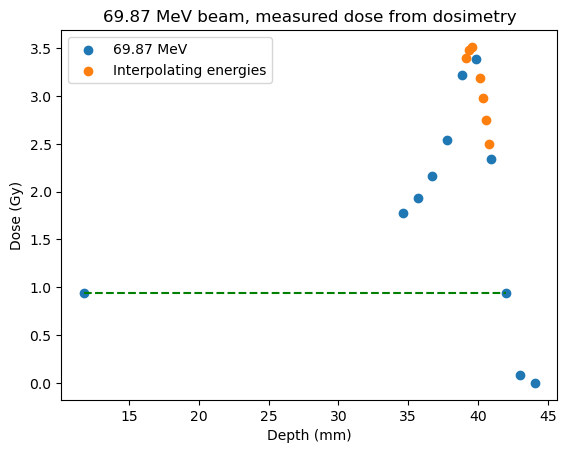

In [7]:
BP_measured = pd.read_excel(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Mid LET calculation\BP 69.87 measured - copy for scripts.xlsx")
RSdepth_m = np.array(BP_measured['Depth (mm)'])
RSdose_m = np.array(BP_measured['Dose (Gy)'])
sort = np.argsort(RSdepth_m)
RSdepth_m = RSdepth_m[sort]
RSdose_m = RSdose_m[sort]
trendline = np.interp(np.arange(10, 45, 0.1), RSdepth_m, RSdose_m)


og = BP_measured[BP_measured['Energy']==69.87]
inter = BP_measured[BP_measured['Energy']!=69.87]

plt.scatter(og['Depth (mm)'], og['Dose (Gy)'], label='69.87 MeV')
plt.scatter(inter['Depth (mm)'], inter['Dose (Gy)'], label='Interpolating energies')
#plt.plot(np.arange(10, 45, 0.1), trendline, linestyle='--', color='grey')
plt.title('69.87 MeV beam, measured dose from dosimetry')
plt.xlabel('Depth (mm)')
plt.ylabel('Dose (Gy)')
plt.legend()
plt.hlines(0.94537, 11.78, 41.97, linestyles='--', colors = 'green')